In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv


In [2]:
# ==========================================================
# House Price Prediction Project
# End-to-End Machine Learning Web Application
# ==========================================================
#
# Project Overview:
# This project aims to predict house prices using Machine Learning.
# Project Workflow:
# 1. Load and explore the dataset.
# 2. Perform data cleaning and preprocessing.
# 3. Conduct Exploratory Data Analysis (EDA).
# 4. Build and compare multiple regression models.
# 5. Evaluate model performance.
# 6. Export the trained model.
# ==========================================================

# Table of Contents

1. Phase 1: Project Setup & Data Understanding
2. Phase 2: Exploratory Data Analysis (EDA)
3. Phase 3: Data Cleaning & Preprocessing
4. Phase 4: Feature Engineering
5. Phase 5: Machine Learning Models
6. Phase 6: Model Export

#  Phase 1: Project Setup & Data Understanding

In this phase, we import the required libraries, configure the visualization settings, load the dataset, and perform an initial exploration of the data. We also inspect the dataset structure, identify numerical and categorical features, analyze missing values, and summarize the dataset before starting the data analysis and preprocessing stages.

In [3]:

# Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:

# Visualization Settings


plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv


In [6]:

# Load Dataset


import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [7]:

# Display First Rows


df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [8]:

# Dataset Shape


print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 187531
Number of Columns : 21


In [9]:

# Dataset Information


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [10]:

# Statistical Summary


df.describe(include="all")

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
count,187531.000000,187531,184508,187531,1.698660e+05,187531,106858,186916,180454,187448,...,117298,106095,77853,186703,138596,84174,122014,79846,0.0,0.0
unique,NaN,32446,65634,1561,NaN,81,2758,1,947,4,...,8,19,10376,11,11,229,4,2976,NaN,NaN
top,NaN,2 BHK Ready to Occupy Flat for sale in Divyasr...,Multistorey apartment is available for sale. I...,Call for Price,NaN,new-delhi,1000 sqft,Ready to Move,2 out of 4,Resale,...,East,Main Road,Hamdam Apartment,2,2,1 Covered,Freehold,1100 sqft,NaN,NaN
freq,NaN,2106,2732,9684,NaN,27599,5285,186916,12433,144172,...,54741,32193,1648,93007,51809,38754,112229,2599,NaN,NaN
mean,93765.000000,NaN,NaN,NaN,7.583772e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,54135.681003,NaN,NaN,NaN,2.724171e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,46882.500000,NaN,NaN,NaN,4.297000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,93765.000000,NaN,NaN,NaN,6.034000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,140647.500000,NaN,NaN,NaN,9.450000e+03,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:

# Column Names


df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

# **Dataset Overview**
In this section, we inspect the dataset to understand its structure, dimensions, data types, and missing values before preprocessing.

In [12]:

# Dataset Dimensions


rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 187531
Number of Columns : 21


In [13]:

# Identify Feature Types


numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area']

Categorical Features
['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area']


In [14]:

# Missing Values Percentage


missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = (
    missing_percentage
    .sort_values(ascending=False)
    .to_frame(name="Missing Percentage")
)

missing_percentage

,Missing Percentage
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352


In [15]:

# Check Duplicate Records


duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicates}")

Number of Duplicate Rows: 0


In [16]:

# Columns with Missing Values


missing_only = missing_percentage[missing_percentage["Missing Percentage"] > 0]

missing_only

,Missing Percentage
Plot Area,100.000000
Dimensions,100.000000
Society,58.485264
Super Area,57.422506
Car Parking,55.114621
overlooking,43.425354
Carpet Area,43.018488
facing,37.451408
Ownership,34.936624
Balcony,26.094352


##  Setup & Data Understanding Summary

After inspecting the dataset:

- The dataset contains **(Rows)** rows and **(Columns)** columns.
- It includes both numerical and categorical features.
- Some columns contain missing values that need preprocessing.
- Columns with the highest percentage of missing values will be handled during the data cleaning phase.

# Phase 2: Exploratory Data Analysis (EDA)

In this phase, we explore the dataset using statistical summaries and visualizations to better understand the distribution of house prices and the relationships between different features.

In [17]:

# Display All Columns


for col in df.columns:
    print(col)

Index
Title
Description
Amount(in rupees)
Price (in rupees)
location
Carpet Area
Status
Floor
Transaction
Furnishing
facing
overlooking
Society
Bathroom
Balcony
Car Parking
Ownership
Super Area
Dimensions
Plot Area


In [18]:

# Data Types


df.dtypes

Index                  int64
Title                 object
Description           object
Amount(in rupees)     object
Price (in rupees)    float64
location              object
Carpet Area           object
Status                object
Floor                 object
Transaction           object
Furnishing            object
facing                object
overlooking           object
Society               object
Bathroom              object
Balcony               object
Car Parking           object
Ownership             object
Super Area            object
Dimensions           float64
Plot Area            float64
dtype: object

In [19]:

# Random Samples


df.sample(5, random_state=42)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
99649,99649,2 BHK Ready to Occupy Flat for sale in One Raj...,The mentioned Price indicates only the Base Pr...,1.20 Cr,9646.0,kolkata,740 sqft,Ready to Move,NaN,New Property,...,NaN,Main Road,One Rajarhat,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
20299,20299,2 BHK Ready to Occupy Flat for sale A Narayana...,This gorgeous 2 BHK Flat is available for sale...,65 Lac,4062.0,bangalore,1050 sqft,Ready to Move,4 out of 4,Resale,...,East,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN
153392,153392,3 BHK Ready to Occupy Flat for sale Doon calli...,Have a look at this immaculate 3 BHK flat for ...,98 Lac,4900.0,dehradun,NaN,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,4,NaN,NaN,NaN,2000 sqft,NaN,NaN
104329,104329,2 BHK Ready to Occupy Flat for sale in One Raj...,The mentioned Price indicates only the Base Pr...,1.20 Cr,9646.0,kolkata,740 sqft,Ready to Move,NaN,New Property,...,NaN,Main Road,One Rajarhat,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
174711,174711,3 BHK Ready to Occupy Flat for sale in Dolphin...,"New Dhamtari Road, Raipur has an attractive 3 ...",44.4 Lac,2700.0,raipur,1300 sqft,Ready to Move,1 out of 8,New Property,...,East,Main Road,Dolphin Jewel O,3,2,1 Covered,Co-operative Society,NaN,NaN,NaN


In [20]:

# Numerical Features


numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)

Index(['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area'], dtype='object')


In [21]:

# Categorical Features


categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area',
       'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='object')


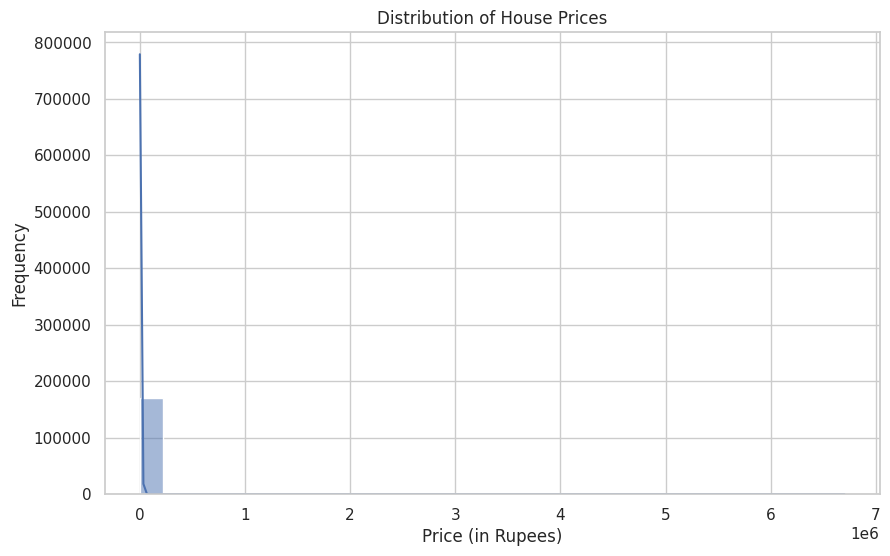

In [22]:

# Distribution of House Prices


plt.figure(figsize=(10,6))

sns.histplot(df["Price (in rupees)"], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("Price (in Rupees)")

plt.ylabel("Frequency")

plt.show()

# Observation
Most houses are concentrated within a specific price range, while a smaller number of properties have very high prices. This indicates the presence of high-value outliers.

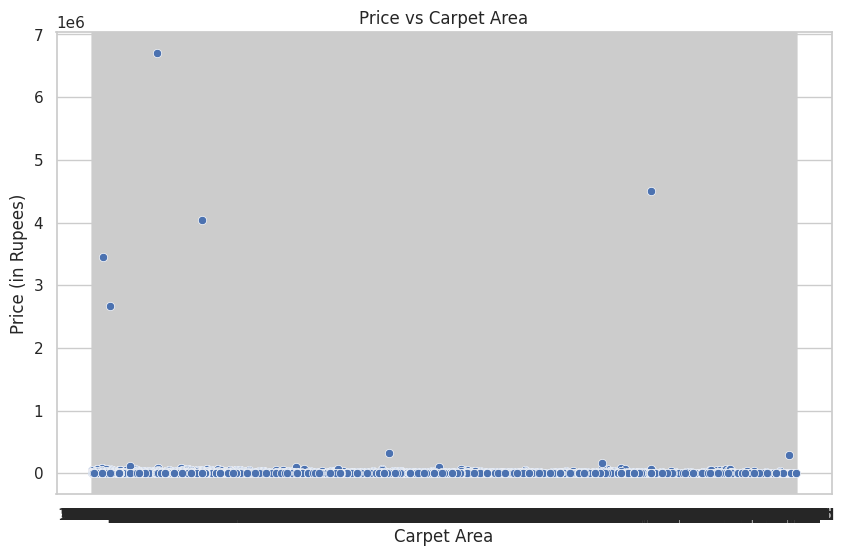

In [23]:

# Price vs Carpet Area


plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Carpet Area"],
    y=df["Price (in rupees)"]
)

plt.title("Price vs Carpet Area")

plt.xlabel("Carpet Area")

plt.ylabel("Price (in Rupees)")

plt.show()

# Observation
This visualization helps identify the relationship between the carpet area and house prices. Generally, larger houses tend to have higher prices, although some outliers may exist.

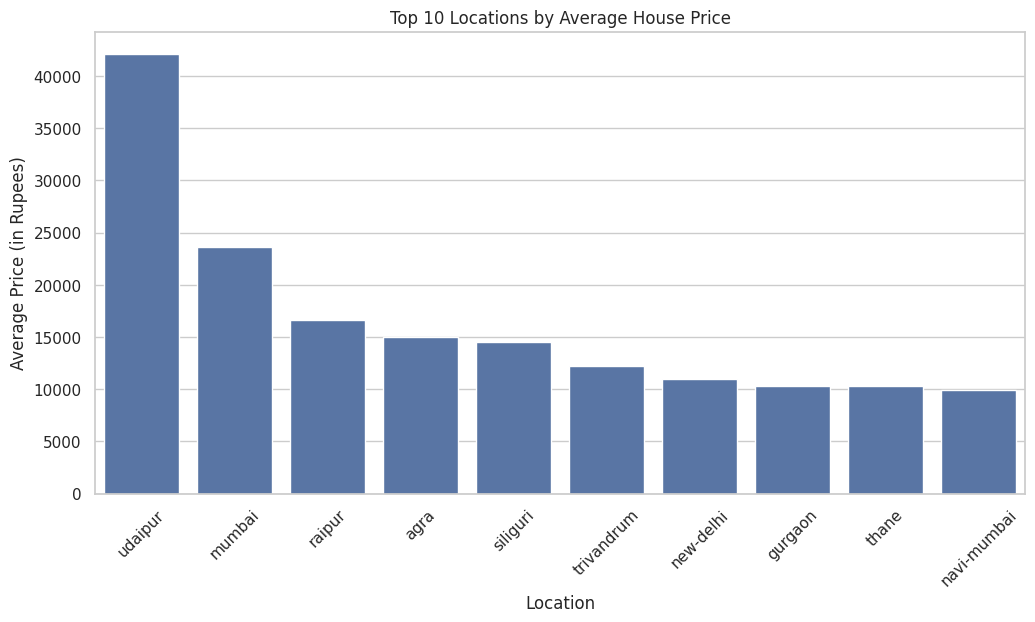

In [24]:

# Top 10 Locations by Average Price


top_locations = (
    df.groupby("location")["Price (in rupees)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)

plt.title("Top 10 Locations by Average House Price")

plt.xlabel("Location")

plt.ylabel("Average Price (in Rupees)")

plt.xticks(rotation=45)

plt.show()

# Observation
The average house prices vary significantly across different locations. Some locations have considerably higher average prices, indicating that location is an important factor affecting house prices.

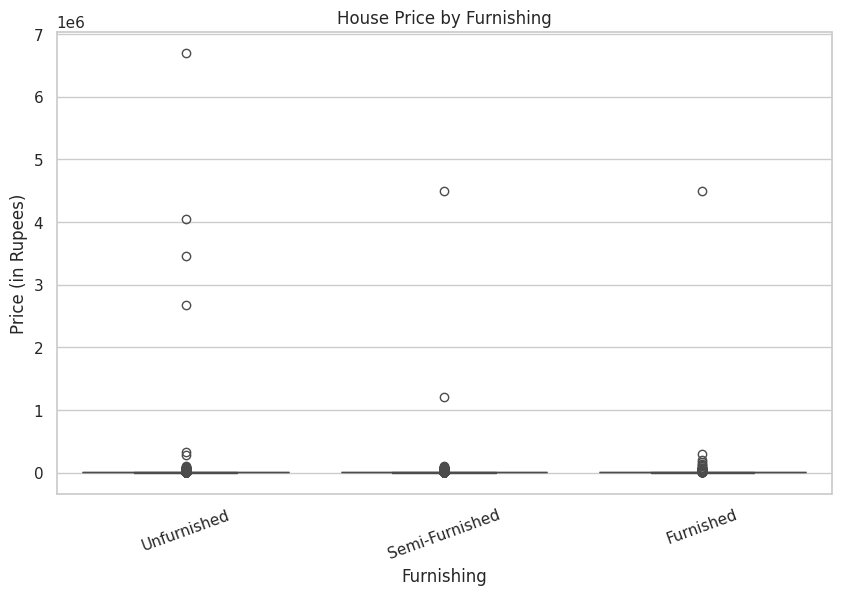

In [25]:

# House Price by Furnishing


plt.figure(figsize=(10,6))

sns.boxplot(
    x="Furnishing",
    y="Price (in rupees)",
    data=df
)

plt.title("House Price by Furnishing")

plt.xlabel("Furnishing")

plt.ylabel("Price (in Rupees)")

plt.xticks(rotation=20)

plt.show()

# Observation
Furnishing status appears to influence house prices. Fully furnished properties generally tend to have higher prices compared to semi-furnished or unfurnished properties.

# Phase 3: Data Cleaning & Feature Engineering

In [26]:
# Create a copy of the dataset for data cleaning
df_clean= df.copy()

### Amount (in rupees)

The Amount (in rupees) column represents the property price. Since the values are stored as text using the Indian numbering system (such as **Lac** and **Cr**), they must be converted into numeric values before machine learning. Some records also contain **"Call for Price"**, which will be treated as missing values.

In [27]:
# Display unique price formats before cleaning
df_clean["Amount(in rupees)"].value_counts().head(20)

Amount(in rupees)
Call for Price    9684
85 Lac            5264
65 Lac            4229
60 Lac            3869
70 Lac            3801
35 Lac            3369
75 Lac            3144
90 Lac            3143
40 Lac            3098
50 Lac            3006
1.75 Cr           2879
30 Lac            2790
25 Lac            2771
51 Lac            2682
45 Lac            2665
1.30 Cr           2561
22 Lac            2537
2.35 Cr           2361
23 Lac            2312
88 Lac            2310
Name: count, dtype: int64

In [28]:
# Convert price values into numeric format
# Indian numbering system:
# 1 Lac = 100,000 Rupees
# 1 Crore (Cr) = 10,000,000 Rupees

def parse_amount(value):

    # Return missing values as they are
    if pd.isna(value):
        return np.nan

    # Convert the value to string and remove extra spaces
    value = str(value).strip()

    # Replace "Call for Price" with NaN
    if value.lower() == "call for price":
        return np.nan

    # Convert values in Lac to numeric rupees
    if "Lac" in value:
        return float(value.replace("Lac", "").strip()) * 100000

    # Convert values in Crore (Cr) to numeric rupees
    if "Cr" in value:
        return float(value.replace("Cr", "").strip()) * 10000000

    # Return NaN for any unexpected format
    return np.nan


In [29]:
# Apply the function to convert the price column into numeric values
df_clean["Amount_numeric"] = df_clean["Amount(in rupees)"].apply(parse_amount)

In [30]:
# Compare the original and converted price columns
df_clean[["Amount(in rupees)", "Amount_numeric"]].head(10)

,Amount(in rupees),Amount_numeric
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [31]:
# Check the number of missing values after conversion
df_clean["Amount_numeric"].isna().sum()

np.int64(9684)

The number of missing values is 9,684, which matches the original count of "Call for Price" entries. This confirms that the conversion function worked correctly and no unintended values were converted to missing values

In [32]:
# Remove rows where the target price is missing
df_clean = df_clean.dropna(subset=["Amount_numeric"])

In [33]:
# Check the dataset shape after removing missing target values
print(df_clean.shape)

(177847, 22)


Observation

The Balcony column has been successfully converted into a numeric feature. Non-numeric values were replaced with missing values (NaN), while the remaining values were converted into numeric format.Original number of rows: 187,531

Rows with missing target values (Call for Price): 9,684

Remaining rows:
187,531 − 9,684 = 177,847

The dataset is now ready for further preprocessing.

### Carpet Area

The Carpet Area column contains property area stored as text with different measurement units such as sqft, sqm, and sqyrd. Since machine learning models require numeric values with a consistent unit, all area values will be converted into square feet (sqft)

In [34]:
# Explore the Carpet Area column

# Most common values
df_clean["Carpet Area"].value_counts().head(20)

# Inspect random samples to identify different formats
df_clean["Carpet Area"].dropna().sample(30, random_state=42)

50673      980 sqft
147849      181 sqm
136494     50 sqyrd
123831    133 sqyrd
69592     1470 sqft
85146      645 sqft
79602     1830 sqft
62296     1296 sqft
142023    1250 sqft
90674     1058 sqft
139191    133 sqyrd
12573      900 sqft
50686     1100 sqft
130168     675 sqft
124275     400 sqft
94869      680 sqft
10570     105 sqyrd
59018     1300 sqft
134337     850 sqft
863        622 sqft
115244     750 sqft
82206     1323 sqft
166924     700 sqft
10065      743 sqft
115702    3000 sqft
163919     980 sqft
184321    1500 sqft
184881    1400 sqft
185634     960 sqft
58462     1470 sqft
Name: Carpet Area, dtype: object

The pattern \d+\.?\d* is used to extract the numeric value from the text.

\d+ → one or more digits.
\.? → an optional decimal point.
\d* → zero or more digits after the decimal point.

In [35]:
import re

# Unit conversion factors
SQM_TO_SQFT = 10.764
SQYRD_TO_SQFT = 9

def parse_area(area):

    # Keep missing values as missing
    if pd.isna(area):
        return np.nan

    area = str(area).strip().lower()

    # Extract the numeric value using Regular Expression
    match = re.search(r"\d+\.?\d*", area)

    if not match:
        return np.nan

    value = float(match.group())

    # Convert all area values to square feet (sqft)
    if "sqft" in area:
        return value
    elif "sqm" in area:
        return value * SQM_TO_SQFT
    elif "sqyrd" in area:
        return value * SQYRD_TO_SQFT

    return np.nan

In [36]:
# Convert Carpet Area into square feet
df_clean["Carpet_Area_sqft"] = df_clean["Carpet Area"].apply(parse_area)

In [37]:
# Compare original and cleaned values
df_clean[["Carpet Area", "Carpet_Area_sqft"]].sample(10, random_state=42)

,Carpet Area,Carpet_Area_sqft
61113,NaN,NaN
155818,900 sqft,900.0
172589,NaN,NaN
120110,1600 sqft,1600.0
154003,1160 sqft,1160.0
99959,NaN,NaN
6909,1707 sqft,1707.0
4313,372 sqft,372.0
82180,NaN,NaN
102315,500 sqft,500.0


In [38]:
# Check missing values after conversion
df_clean["Carpet_Area_sqft"].isna().sum()

np.int64(76333)

In [39]:
df_clean["Carpet Area"].isna().sum()

np.int64(76325)

In [40]:
df_clean[df_clean["Carpet_Area_sqft"].isna()]["Carpet Area"].value_counts().head(30)

Carpet Area
14 marla      2
1 kanal       2
2 acre        1
1500 acre     1
1607 bigha    1
3 ground      1
Name: count, dtype: int64

Observation

The Balcony column has been successfully converted into a numeric feature. Non-numeric values were replaced with missing values (NaN), while the remaining values were converted into numeric format.After conversion, the number of missing values increased from 76,325 to 76,333. The additional 8 missing values correspond to unsupported area units such as marla, kanal, acre, bigha, and ground. Since these units are extremely rare and do not have consistent conversion factors across regions, they were treated as missing values

### Super Area

The Super Area column represents the total area of the property, including the usable area and a proportion of common spaces such as corridors, elevators, and shared facilities. Since the values are stored as text with the unit **"sqft"**, they must be converted into numeric values before machine learning.

In [41]:
df_clean["Super Area"].dropna().sample(30, random_state=42)

423        395 sqft
166664    1425 sqft
60146      700 sqft
153597    1950 sqft
58169     1081 sqft
161602    1825 sqft
26699     1070 sqft
65970     1494 sqft
84695     1788 sqft
125116    1850 sqft
146347    1534 sqft
148858     560 sqft
101926    1435 sqft
173035     504 sqft
42679     1400 sqft
7558      200 sqyrd
168852    1560 sqft
103996    1435 sqft
53854     1932 sqft
27193      910 sqft
41737      600 sqft
177380    1936 sqft
183046    1176 sqft
19382     2500 sqft
158829    1000 sqft
43909     1400 sqft
102911    1705 sqft
76090     1250 sqft
80339     1195 sqft
139621     500 sqft
Name: Super Area, dtype: object

In [42]:
# Explore the Super Area column
df_clean["Super Area"].value_counts().head(20)

Super Area
1100 sqft    2567
1332 sqft    2110
1500 sqft    1998
500 sqft     1651
1000 sqft    1294
1450 sqft    1014
1300 sqft     990
1850 sqft     937
1250 sqft     903
1650 sqft     883
140 sqyrd     841
45 sqyrd      830
700 sqft      824
2500 sqft     783
600 sqft      781
1060 sqft     779
1180 sqft     774
1140 sqft     773
1675 sqft     759
1160 sqft     758
Name: count, dtype: int64

In [43]:
# Convert Super Area into square feet
df_clean["Super_Area_sqft"] = df_clean["Super Area"].apply(parse_area)

In [44]:
# Compare original and cleaned values
df_clean[["Super Area", "Super_Area_sqft"]].sample(10, random_state=42)

,Super Area,Super_Area_sqft
61113,1149 sqft,1149.0
155818,NaN,NaN
172589,1025 sqft,1025.0
120110,NaN,NaN
154003,NaN,NaN
99959,1017 sqft,1017.0
6909,NaN,NaN
4313,NaN,NaN
82180,1250 sqft,1250.0
102315,NaN,NaN


In [45]:
# Display unsupported area units that were converted to missing values
df_clean[df_clean["Super_Area_sqft"].isna()]["Super Area"].value_counts()

Super Area
8 marla           4
5 marla           2
1810 marla        1
4 marla           1
700 ground        1
485 aankadam      1
2 kanal           1
998 acre          1
585 ground        1
1080 kanal        1
2800 kanal        1
2 cent            1
530,040 ground    1
Name: count, dtype: int64

Observation

The Balcony column has been successfully converted into a numeric feature. Non-numeric values were replaced with missing values (NaN), while the remaining values were converted into numeric format.After conversion, the number of missing values increased from 101,612 to 101,629. The additional 17 missing values correspond to unsupported area units such as marla, ground, kanal, acre, aankadam, and cent. Since these units are extremely rare and do not have consistent conversion factors, they were treated as missing values.

### Floor

The Floor column represents the floor level of the property. The values are stored as text (e.g., **"3 out of 10"**), so the floor number needs to be extracted into a numeric format before machine learning.

In [46]:
# Explore the Floor column
df_clean["Floor"].value_counts().head(20)

Floor
1 out of 4          11801
2 out of 4          11437
3 out of 4           7804
1 out of 3           6934
2 out of 3           5868
4 out of 4           5814
3 out of 3           4405
2 out of 5           4331
4 out of 5           3723
3 out of 6           3579
3 out of 5           3360
2 out of 2           3350
1 out of 5           3319
1 out of 2           2829
Ground out of 4      2778
5 out of 5           2405
8 out of 10          2381
Ground out of 10     2154
3 out of 10          1967
4 out of 8           1888
Name: count, dtype: int64

In [47]:
# Display random samples to inspect different floor formats
df_clean["Floor"].dropna().sample(30, random_state=42)

93167       1 out of 4
105931      4 out of 4
56196       1 out of 4
141716      2 out of 4
60474      2 out of 20
11194       5 out of 7
164806    12 out of 25
181620      1 out of 4
147321     5 out of 22
182538      2 out of 5
93032     12 out of 14
166394      4 out of 7
152157      3 out of 8
159422      3 out of 3
40691       1 out of 4
166297      2 out of 6
11807      5 out of 11
175657      7 out of 9
110900      3 out of 3
69893      5 out of 13
154103    13 out of 14
157561      2 out of 4
39507      2 out of 10
131198      5 out of 7
173587      6 out of 8
21460      7 out of 32
5486        3 out of 5
181277      5 out of 7
4565        6 out of 7
36284       2 out of 4
Name: Floor, dtype: object

In [48]:
# Display random unique floor formats
pd.Series(df_clean["Floor"].dropna().unique()).sample(50, random_state=42)

70                  5 out of 12
331                 8 out of 14
858                45 out of 45
495                18 out of 39
209                19 out of 20
863                11 out of 45
30                  1 out of 27
893                11 out of 84
250                 6 out of 22
541                18 out of 35
689                24 out of 27
86                   1 out of 6
708     Upper Basement out of 6
136                19 out of 24
39                  7 out of 16
351                16 out of 29
137                 7 out of 19
693                 3 out of 26
444                28 out of 60
753                17 out of 33
720                           3
247                 5 out of 27
239                17 out of 30
857                27 out of 33
887                21 out of 31
915                 2 out of 67
439                13 out of 36
675            Ground out of 18
759                 7 out of 40
306                 2 out of 11
280                13 out of 42
717     

In [49]:
# Convert floor information into numeric features
def parse_floor(floor):

    # Keep missing values as missing
    if pd.isna(floor):
        return np.nan, np.nan

    # Convert the value to string and remove extra spaces
    floor = str(floor).strip()

    # Handle Ground Floor
    if "Ground" in floor:
        match = re.search(r"out of (\d+)", floor)

        if match:
            return 0, int(match.group(1))

        return 0, np.nan

    # Handle Upper Basement
    if "Upper Basement" in floor:
        match = re.search(r"out of (\d+)", floor)

        if match:
            return -1, int(match.group(1))

        return -1, np.nan

    # Handle Lower Basement
    if "Lower Basement" in floor:
        match = re.search(r"out of (\d+)", floor)

        if match:
            return -2, int(match.group(1))

        return -2, np.nan

    # Handle values in the format "X out of Y"
    match = re.match(r"(\d+)\s+out of\s+(\d+)", floor)

    if match:
        floor_number = int(match.group(1))
        total_floors = int(match.group(2))

        return floor_number, total_floors

    # Handle values that contain only the floor number
    if floor.isdigit():
        return int(floor), np.nan

    # Return missing values for unsupported formats
    return np.nan, np.nan

In [50]:
# Apply the function to extract floor information
df_clean[["Floor_Number", "Total_Floors"]] = df_clean["Floor"].apply(
    lambda x: pd.Series(parse_floor(x))
)

In [51]:
# Compare the original and cleaned floor columns
df_clean[["Floor", "Floor_Number", "Total_Floors"]].sample(10, random_state=42)

,Floor,Floor_Number,Total_Floors
61113,Ground out of 2,0.0,2.0
155818,4 out of 4,4.0,4.0
172589,10 out of 12,10.0,12.0
120110,7 out of 10,7.0,10.0
154003,2 out of 2,2.0,2.0
99959,1 out of 7,1.0,7.0
6909,6 out of 14,6.0,14.0
4313,2 out of 4,2.0,4.0
82180,4 out of 9,4.0,9.0
102315,Ground out of 5,0.0,5.0


Observation

The Balcony column has been successfully converted into a numeric feature. Non-numeric values were replaced with missing values (NaN), while the remaining values were converted into numeric format.Total_Floors. The number of missing values in Floor_Number remained unchanged, confirming that no additional missing values were introduced during the conversion. The Total_Floors column contains 46 additional missing values, corresponding to records where only the floor number was available (e.g., "3"), while the total number of floors was not provided.

### Bathroom

The Bathroom column represents the number of bathrooms available in each property. Since the values are stored as text, they need to be converted into numeric values before machine learning.

In [52]:
# Explore and clean the Bathroom column

df_clean["Bathroom"].head(10)

df_clean["Bathroom"].value_counts().head(20)

Bathroom
2       88999
3       54187
1       15509
4       14826
5        3281
6         187
7          32
> 10       29
8          14
10         12
9          11
Name: count, dtype: int64

In [53]:
# Clean the Bathroom column and convert it to numeric values

df_clean["Bathroom"] = df_clean["Bathroom"].replace("> 10", np.nan)

df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"])

In [54]:
# Validate the Bathroom column after cleaning

print(df_clean["Bathroom"].dtype)

print(df_clean["Bathroom"].unique())

float64
[ 1.  2.  3.  4.  6. nan  5.  9.  8.  7. 10.]


Observation

The Balcony column has been successfully converted into a numeric feature. Non-numeric values were replaced with missing values (NaN), while the remaining values were converted into numeric format.

The Bathroom column has been successfully converted into a numeric feature. Missing values remain as NaN and will be handled later during the missing value treatment phase.

### Balcony

The Balcony column represents the number of balconies available in each property. Since the values are stored as text, they need to be converted into numeric values before machine learning.

In [55]:
# Explore and clean the Balcony column

display(df_clean["Balcony"].head(10))

display(df_clean["Balcony"].value_counts().head(20))

0      2
1    NaN
2    NaN
3      1
4    NaN
5      1
6    NaN
7    NaN
8    NaN
9      1
Name: Balcony, dtype: object

Balcony
2       50311
1       45145
3       24958
4        9275
5         814
6         127
> 10       16
7          14
10         13
8          13
9           2
Name: count, dtype: int64

In [56]:
# Clean the Balcony column and convert it to numeric values

df_clean["Balcony"] = df_clean["Balcony"].replace("> 10", np.nan)

df_clean["Balcony"] = pd.to_numeric(df_clean["Balcony"])

In [57]:
# Validate the Balcony column after cleaning

print(df_clean["Balcony"].dtype)

print(df_clean["Balcony"].unique())

float64
[ 2. nan  1.  3.  4.  6.  5.  7. 10.  8.  9.]



Observation

The Balcony column has been successfully converted into a numeric feature. Non-numeric values were replaced with missing values (NaN), while the remaining values were converted into numeric format.


### Car Parking

The Car Parking column represents the number of parking spaces available for each property. Since the values are stored as text, they need to be converted into numeric values before machine learning.

In [58]:
# Explore and clean the Car Parking column

display(df_clean["Car Parking"].head(10))

display(df_clean["Car Parking"].value_counts().head(20))

0          NaN
1       1 Open
2    1 Covered
3          NaN
4    1 Covered
5          NaN
6          NaN
7          NaN
8          NaN
9    1 Covered
Name: Car Parking, dtype: object

Car Parking
1 Covered      37760
1 Covered,     16893
2 Covered      10020
1 Open          7697
2 Covered,      3968
2 Open          2560
10 Open          843
34 Covered       573
3 Covered        394
402 Covered      317
3 Covered,       138
4 Covered        109
5 Covered         33
3 Open            32
4 Covered,        27
4 Open            26
15 Covered        24
6 Covered         23
5 Open            23
8 Covered         22
Name: count, dtype: int64

In [59]:
# Extract the number of parking spaces and convert it to numeric

df_clean["Car Parking"] = (
    df_clean["Car Parking"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

df_clean["Car Parking"] = pd.to_numeric(df_clean["Car Parking"])

In [60]:
# Validate the Car Parking column after cleaning

print(df_clean["Car Parking"].dtype)

print(df_clean["Car Parking"].head(10))

float64
0    NaN
1    1.0
2    1.0
3    NaN
4    1.0
5    NaN
6    NaN
7    NaN
8    NaN
9    1.0
Name: Car Parking, dtype: float64


Observation

The Car Parking column has been successfully converted into a numeric feature by extracting the number of parking spaces from the original text. Missing values remain as NaN and will be handled later during the missing value treatment phase.

### Drop Useless Columns

The `Dimensions` and `Plot Area` columns contain no useful information because all their values are missing. Therefore, they are removed from the dataset.

In [61]:
# Drop columns that contain only missing values

df_clean = df_clean.drop(columns=["Dimensions", "Plot Area"])

In [62]:
# Verify that the useless columns have been removed

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  object 
 2   Description        174918 non-null  object 
 3   Amount(in rupees)  177847 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           177847 non-null  object 
 6   Carpet Area        101522 non-null  object 
 7   Status             177252 non-null  object 
 8   Floor              170898 non-null  object 
 9   Transaction        177780 non-null  object 
 10  Furnishing         175780 non-null  object 
 11  facing             112111 non-null  object 
 12  overlooking        102022 non-null  object 
 13  Society            74928 non-null   object 
 14  Bathroom           177058 non-null  float64
 15  Balcony            130672 non-null  float64
 16  Car Par

Observation

The `Dimensions` and `Plot Area` columns were successfully removed because they contained only missing values and provided no useful information for model training.

### Location

The `location` column contains a very large number of unique values (high cardinality). To reduce the dimensionality of the dataset, only the most frequent locations will be kept, while the remaining locations will be grouped into a single category called **Other** before one-hot encoding.

In [63]:
# Explore the location column

display(df_clean["location"].head(10))

print(df_clean["location"].nunique())

display(df_clean["location"].value_counts().head(20))

0    thane
1    thane
2    thane
3    thane
4    thane
5    thane
6    thane
7    thane
8    thane
9    thane
Name: location, dtype: object

81


location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
noida             1247
Name: count, dtype: int64

Observation

Although the project guide recommends grouping locations when the column has thousands of unique values (high cardinality), this dataset contains only 81 unique locations. Therefore, all locations were retained without grouping into **Other**.

### Society

The `Society` column contains a very large number of unique values (high cardinality). To reduce the dimensionality of the dataset, only the most frequent societies will be kept, while the remaining societies will be grouped into **Other** before one-hot encoding.

In [64]:
# Explore the Society column

display(df_clean["Society"].head(10))

print(df_clean["Society"].nunique())

display(df_clean["Society"].value_counts().head(20))

0    Srushti Siddhi Mangal Murti Complex
1                            Dosti Vihar
2                   Sunrise by Kalpataru
3                                    NaN
4            TenX Habitat Raymond Realty
5                           Virat Aangan
6                                    NaN
7                                    NaN
8                                    NaN
9                            Pride Palms
Name: Society, dtype: object

10068


Society
Hamdam Apartment                1648
Malibu Town                     1158
Shree Vardhman Victoria         1154
DLF Skycourt                    1153
Nebula Tower                     982
Harmony Apartment                828
Defence Officers Apartment       827
East of Kailash                  826
Sarve Satyam Apartment           825
Rama Apartment                   823
DDA Flat                         823
CGHS Apoorva Apartments          821
Him Hit Sadbhavna Apartments     821
Aadarsh Apartment                821
DDA Sanskriti Apartments         821
Madhur Jeevan Apartment          821
Kesarwani Apartment              821
DLF New Town Heights             666
Elita Garden Vista               655
Rare Earth                       653
Name: count, dtype: int64

In [65]:
# Keep only the top 50 most frequent societies

top_societies = df_clean["Society"].value_counts().head(50).index

df_clean["Society"] = df_clean["Society"].apply(
    lambda x: x if x in top_societies else "Other"
)

In [66]:
# Validate the Society column after grouping rare categories

print(df_clean["Society"].nunique())

display(df_clean["Society"].value_counts().head(20))

51


Society
Other                           141671
Hamdam Apartment                  1648
Malibu Town                       1158
Shree Vardhman Victoria           1154
DLF Skycourt                      1153
Nebula Tower                       982
Harmony Apartment                  828
Defence Officers Apartment         827
East of Kailash                    826
Sarve Satyam Apartment             825
DDA Flat                           823
Rama Apartment                     823
Aadarsh Apartment                  821
Madhur Jeevan Apartment            821
Him Hit Sadbhavna Apartments       821
Kesarwani Apartment                821
DDA Sanskriti Apartments           821
CGHS Apoorva Apartments            821
DLF New Town Heights               666
Elita Garden Vista                 655
Name: count, dtype: int64

### Observation

The Society column originally contained more than 10,000 unique categories, making it a high-cardinality feature. To reduce dimensionality before one-hot encoding, only the 50 most frequent societies were retained, while the remaining categories were grouped into **Other**.

# Data Preprocessing

This section prepares the cleaned dataset for machine learning by handling missing values, encoding categorical features, and removing outliers.

### Drop Redundant Columns

The original text-based columns were replaced with cleaned numeric features. Therefore, the original columns are removed to avoid duplicate information.

In [67]:
# Drop original columns after creating their cleaned numeric versions

df_clean = df_clean.drop(columns=[
    "Amount(in rupees)",
    "Carpet Area",
    "Super Area",
    "Floor"
])

In [68]:
# Verify the remaining columns

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177847 entries, 0 to 187530
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              177847 non-null  int64  
 1   Title              177847 non-null  object 
 2   Description        174918 non-null  object 
 3   Price (in rupees)  169866 non-null  float64
 4   location           177847 non-null  object 
 5   Status             177252 non-null  object 
 6   Transaction        177780 non-null  object 
 7   Furnishing         175780 non-null  object 
 8   facing             112111 non-null  object 
 9   overlooking        102022 non-null  object 
 10  Society            177847 non-null  object 
 11  Bathroom           177058 non-null  float64
 12  Balcony            130672 non-null  float64
 13  Car Parking        81935 non-null   float64
 14  Ownership          115922 non-null  object 
 15  Amount_numeric     177847 non-null  float64
 16  Carpet_

### Handle Missing Values

In [69]:
# Check missing values in the dataset

missing_values = df_clean.isna().sum().sort_values(ascending=False)

display(missing_values[missing_values > 0])

Super_Area_sqft      101629
Car Parking           95912
Carpet_Area_sqft      76333
overlooking           75825
facing                65736
Ownership             61925
Balcony               47175
Price (in rupees)      7981
Total_Floors           6995
Floor_Number           6949
Description            2929
Furnishing             2067
Bathroom                789
Status                  595
Transaction              67
dtype: int64

In [70]:
# Fill missing values in numeric columns using the median

numeric_columns = [
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Floor_Number",
    "Total_Floors"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [71]:
# Check missing values after filling numeric features

df_clean[numeric_columns].isna().sum()

Bathroom        0
Balcony         0
Car Parking     0
Floor_Number    0
Total_Floors    0
dtype: int64

### Observation

Missing values in the selected numeric features were successfully replaced using the median. All missing values in these columns have been removed.

### Drop Unused Text Columns

The `Title` and `Description` columns contain free-text information. Since this project does not use natural language processing (NLP), these columns are removed before model training.

In [72]:
# Drop text columns that will not be used for machine learning

df_clean = df_clean.drop(columns=["Title", "Description"])

### Handle Missing Values in Categorical Features

Categorical features are completed using the most frequent value (mode), since these columns contain descriptive categories rather than numeric values.

In [73]:
# Fill missing values in categorical columns using the mode

categorical_columns = [
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [74]:
# Check missing values after filling categorical features

df_clean[categorical_columns].isna().sum()

Status         0
Transaction    0
Furnishing     0
facing         0
overlooking    0
Ownership      0
dtype: int64

### Observation

Missing values in the categorical features were successfully replaced using the most frequent category (mode).

In [75]:
# Check missing values in the entire dataset

missing_values = df_clean.isna().sum().sort_values(ascending=False)

display(missing_values[missing_values > 0])

Super_Area_sqft      101629
Carpet_Area_sqft      76333
Price (in rupees)      7981
dtype: int64

### Observation

Only three columns still contain missing values:

- `Super_Area_sqft`
- `Carpet_Area_sqft`
- `Price (in rupees)`

The missing values in the area-related features were intentionally left unchanged because a large proportion of their values is missing. Imputing such a high percentage of missing data could introduce bias and reduce data quality.

### Remove Outliers

To identify abnormal property prices, a temporary area feature is created by using the **Super Area** when available, and the **Carpet Area** otherwise.

A temporary **Price per sqft** feature is then calculated. Listings with extremely low or extremely high price per square foot values are considered outliers and removed.

The temporary features are removed after cleaning because they are only used for outlier detection.

In [76]:
# Create a temporary area feature using the available area information

df_clean["Area_sqft"] = df_clean["Super_Area_sqft"].fillna(df_clean["Carpet_Area_sqft"])

In [77]:
# Compare the original area columns with the temporary area feature

df_clean[
    ["Super_Area_sqft", "Carpet_Area_sqft", "Area_sqft"]
].sample(10, random_state=42)

,Super_Area_sqft,Carpet_Area_sqft,Area_sqft
61113,1149.0,NaN,1149.0
155818,NaN,900.0,900.0
172589,1025.0,NaN,1025.0
120110,NaN,1600.0,1600.0
154003,NaN,1160.0,1160.0
99959,1017.0,NaN,1017.0
6909,NaN,1707.0,1707.0
4313,NaN,372.0,372.0
82180,1250.0,NaN,1250.0
102315,NaN,500.0,500.0


In [78]:
# Calculate the temporary price per square foot feature

df_clean["Price_per_sqft"] = (
    df_clean["Amount_numeric"] / df_clean["Area_sqft"]
)

In [79]:
# Display summary statistics for the price per square foot feature

df_clean["Price_per_sqft"].describe()

count    1.777320e+05
mean     1.242286e+04
std      3.380015e+05
min      3.830877e+00
25%      4.700855e+03
50%      6.666667e+03
75%      1.034483e+04
max      5.454545e+07
Name: Price_per_sqft, dtype: float64

In [80]:
# Calculate the lower and upper percentile thresholds

lower_limit = df_clean["Price_per_sqft"].quantile(0.01)
upper_limit = df_clean["Price_per_sqft"].quantile(0.99)

print(f"1st Percentile : {lower_limit:.2f}")
print(f"99th Percentile: {upper_limit:.2f}")

1st Percentile : 2265.62
99th Percentile: 33882.35


In [81]:
# Remove listings with extreme price per square foot values

df_clean = df_clean[
    (df_clean["Price_per_sqft"] >= lower_limit) &
    (df_clean["Price_per_sqft"] <= upper_limit)
]

In [82]:

     # Check the dataset size after removing outliers

print(f"Dataset shape: {df_clean.shape}")
print(f"Rows removed: {177847 - len(df_clean)}")

Dataset shape: (174237, 20)
Rows removed: 3610


In [83]:
# Remove temporary features used for outlier detection

df_clean = df_clean.drop(columns=["Area_sqft", "Price_per_sqft"])

In [84]:
"Area_sqft" in df_clean.columns, "Price_per_sqft" in df_clean.columns

(False, False)

### Observation

Extreme property listings were identified using the **Price per sqft** feature. Listings below the 1st percentile and above the 99th percentile were removed to reduce the effect of abnormal values.

The temporary features were removed after completing the cleaning process because they were created only for outlier detection.

In [85]:
# Final dataset information after cleaning

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174237 entries, 0 to 187530
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              174237 non-null  int64  
 1   Price (in rupees)  166453 non-null  float64
 2   location           174237 non-null  object 
 3   Status             174237 non-null  object 
 4   Transaction        174237 non-null  object 
 5   Furnishing         174237 non-null  object 
 6   facing             174237 non-null  object 
 7   overlooking        174237 non-null  object 
 8   Society            174237 non-null  object 
 9   Bathroom           174237 non-null  float64
 10  Balcony            174237 non-null  float64
 11  Car Parking        174237 non-null  float64
 12  Ownership          174237 non-null  object 
 13  Amount_numeric     174237 non-null  float64
 14  Carpet_Area_sqft   99517 non-null   float64
 15  Super_Area_sqft    74720 non-null   float64
 16  Floor_N

In [86]:
# Final dataset shape

print(df_clean.shape)

(174237, 18)


## Data Cleaning & Feature Engineering Summary

In this notebook, the dataset was cleaned and prepared for the next stage of the project. The following preprocessing steps were completed:

- Converted the property price from text to a numeric format.
- Standardized the area features and converted all values to square feet (sqft).
- Extracted floor information into numeric features.
- Converted Bathroom, Balcony, and Car Parking to numeric values and handled missing values.
- Reduced the cardinality of the **location** and **Society** features by keeping the top 50 categories and grouping the remaining values as **Other**.
- Removed unnecessary columns.
- Detected and removed outliers using the **Price per sqft** feature.

The cleaned dataset is now ready for the next stage, including feature encoding and machine learning model development.

# Build, Train & Evaluate the Machine Learning Models

In [87]:
#  Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Basic libraries imported")

Basic libraries imported


In [88]:
#  Import Scikit-Learn modules & Export tools
import joblib
import json
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("ML libraries imported")

ML libraries imported


In [89]:
print(df_clean.columns.tolist())

['Index', 'Price (in rupees)', 'location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Amount_numeric', 'Carpet_Area_sqft', 'Super_Area_sqft', 'Floor_Number', 'Total_Floors']


In [90]:

# Define feature columns and target

numeric_features = [
    "Carpet_Area_sqft",
    "Floor_Number",
    "Bathroom",
    "Balcony",
    "Car Parking",
    "Total_Floors"
]

categorical_features = [
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

X = df_clean[numeric_features + categorical_features]
y = df_clean["Amount_numeric"]

print("Features selected!")

Features selected!


In [91]:
#  Apply Log Transformation to target (price)
y_log = np.log1p(y)

print("Target transformed using log1p")

Target transformed using log1p


In [92]:
#  Split data into train (80%) and test (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test = np.expm1(y_test_log)

print("Data split completed")

Data split completed


In [93]:
#  Create ColumnTransformer for scaling and encoding
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

print("Preprocessor built")

Preprocessor built


In [94]:
#  Filter out any rows containing NaN or Infinite values in y and X
valid_mask = ~np.isnan(y_train_log) & ~np.isinf(y_train_log)

X_train = X_train[valid_mask]
y_train_log = y_train_log[valid_mask]

#  Build and train the Linear Regression pipeline
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

model_lr.fit(X_train, y_train_log)
print("Linear Regression trained successfully")

Linear Regression trained successfully


In [95]:
# Train Model 2 (Random Forest - 50 trees for fast execution)
model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])

model_rf.fit(X_train, y_train_log)
print("Random Forest trained")

Random Forest trained


In [96]:
# Import required evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#  Generate predictions in log scale
pred_lr_log = model_lr.predict(X_test)
pred_rf_log = model_rf.predict(X_test)

#  Inverse transform predictions to original scale
pred_lr = np.expm1(pred_lr_log)
pred_rf = np.expm1(pred_rf_log)

#  Clean y_test and filter predictions to remove NaNs/Infs
valid_test_mask = ~np.isnan(y_test) & ~np.isinf(y_test)

y_test_clean = y_test[valid_test_mask]
pred_lr_clean = np.nan_to_num(pred_lr[valid_test_mask], nan=0.0)
pred_rf_clean = np.nan_to_num(pred_rf[valid_test_mask], nan=0.0)

#  Calculate RMSE safely
rmse_lr = np.sqrt(mean_squared_error(y_test_clean, pred_lr_clean))
rmse_rf = np.sqrt(mean_squared_error(y_test_clean, pred_rf_clean))

#  Create results DataFrame
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mean_absolute_error(y_test_clean, pred_lr_clean), mean_absolute_error(y_test_clean, pred_rf_clean)],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_score(y_test_clean, pred_lr_clean), r2_score(y_test_clean, pred_rf_clean)]
})

print(results_df.to_string(index=False))

                  Model          MAE         RMSE     R2 Score
      Linear Regression 7.763232e+06 5.125925e+08 -1861.126915
Random Forest Regressor 1.594929e+06 4.847097e+06     0.833495


### Model Comparison

The Random Forest Regressor achieved the best performance among the evaluated models. It produced the highest R² score (0.833) and the lowest MAE and RMSE values, indicating more accurate and reliable predictions than Linear Regression. Therefore, Random Forest was selected as the final model for deployment.

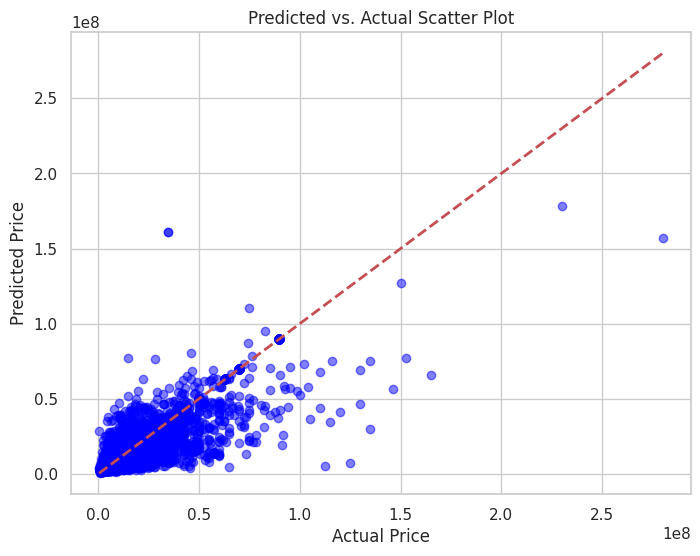

In [97]:
# . Select best model and plot Predicted vs Actual using clean data
r2_rf = r2_score(y_test_clean, pred_rf_clean)
r2_lr = r2_score(y_test_clean, pred_lr_clean)

best_model = model_rf if r2_rf > r2_lr else model_lr
best_pred = pred_rf_clean if r2_rf > r2_lr else pred_lr_clean

plt.figure(figsize=(8, 6))
plt.scatter(y_test_clean, best_pred, alpha=0.5, color="blue")
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. Actual Scatter Plot")
plt.grid(True)
plt.show()

In [98]:
#  Save trained model to PKL and perform sanity check
joblib.dump(best_model, "house_price.pkl")

loaded_model = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Model reloaded! Sample prediction:", np.expm1(loaded_model.predict(sample))[0])

Model reloaded! Sample prediction: 5261874.945643864


In [99]:
import json
import sklearn

# 1. Determine the correct location column name safely
loc_col = "location_grouped" if "location_grouped" in df_clean.columns else "location"

# 2. Extract unique locations and save to JSON
unique_locations = sorted(df_clean[loc_col].dropna().unique().tolist())

with open("locations.json", "w") as f:
    json.dump(unique_locations, f)

# 3. Display completion message and scikit-learn version
print(f"Saved {len(unique_locations)} locations from '{loc_col}' to 'locations.json'")
print("scikit-learn version:", sklearn.__version__)

Saved 81 locations from 'location' to 'locations.json'
scikit-learn version: 1.6.1


# Final Summary

In this project, a complete machine learning workflow was developed for house price prediction.

The dataset was explored, cleaned, and transformed by converting prices and area measurements, handling missing values, reducing high-cardinality categorical features, and removing outliers.

A preprocessing pipeline was built using ColumnTransformer, including feature scaling for numerical variables and one-hot encoding for categorical variables.

Two regression models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² Score. Based on the evaluation results, the Random Forest Regressor achieved the best performance and was selected as the final model.

Finally, the trained model was exported as `house_price.pkl`, and the processed locations were saved in `locations.json` for future deployment.